Wczytujemy dane z cache i dzielimy je na zbiory treningowy oraz testowy.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import librosa
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
)

In [3]:
# Audio params used across feature extraction and CNN
SAMPLE_RATE   = 16_000
CLIP_DURATION = 10
N_MELS        = 128
N_FFT         = 1024
HOP_LENGTH    = 512
N_MFCC        = 40

def load_audio(path: str, sr: int = SAMPLE_RATE, duration: float = CLIP_DURATION) -> np.ndarray:
    """Load a .wav file, resample to `sr`, and fix length to `duration` seconds."""
    wav, _ = librosa.load(path, sr=sr, mono=True)
    target_len = int(sr * duration)
    if len(wav) < target_len:
        wav = np.pad(wav, (0, target_len - len(wav)))
    else:
        wav = wav[:target_len]
    return wav.astype(np.float32)

In [4]:
cache = np.load("features_cache.npz", allow_pickle=True)
X_all         = cache["X"]
y_label       = cache["y_label"]
y_machine     = cache["y_machine"]
file_index    = cache["file_index"].tolist()

df_cache = pd.read_csv("file_index.csv")
fan_mask  = df_cache["machine_type"].values == "fan"

X  = X_all[fan_mask]
y  = y_label[fan_mask]

print(f"Fan samples  : {len(X)}")
print(f"Normal       : {(y == 0).sum()}")
print(f"Abnormal     : {(y == 1).sum()}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")

Fan samples  : 5550
Normal       : 4075
Abnormal     : 1475

Train: (4440, 80), Test: (1110, 80)


Trenujemy bazowy Random Forest i oceniamy go na zbiorze testowym.

=== Random Forest ===
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00       815
    abnormal       1.00      1.00      1.00       295

    accuracy                           1.00      1110
   macro avg       1.00      1.00      1.00      1110
weighted avg       1.00      1.00      1.00      1110

ROC-AUC: 1.0000


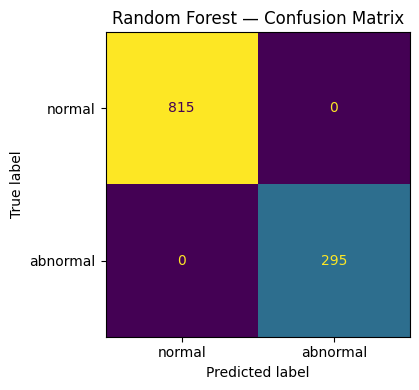

In [5]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf   = rf.predict(X_test)
y_proba_rf  = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=["normal", "abnormal"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf),
                       display_labels=["normal", "abnormal"]).plot(ax=ax, colorbar=False)
ax.set_title("Random Forest — Confusion Matrix")
plt.tight_layout()
plt.savefig("rf_confusion_matrix.png", dpi=150)
plt.show()

Pokazujemy, ktore cechy MFCC sa najwazniejsze w Random Forest.

C:\Users\mikiz\AppData\Local\Temp\ipykernel_15864\1648644974.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x="importance", y="feature", palette="viridis")


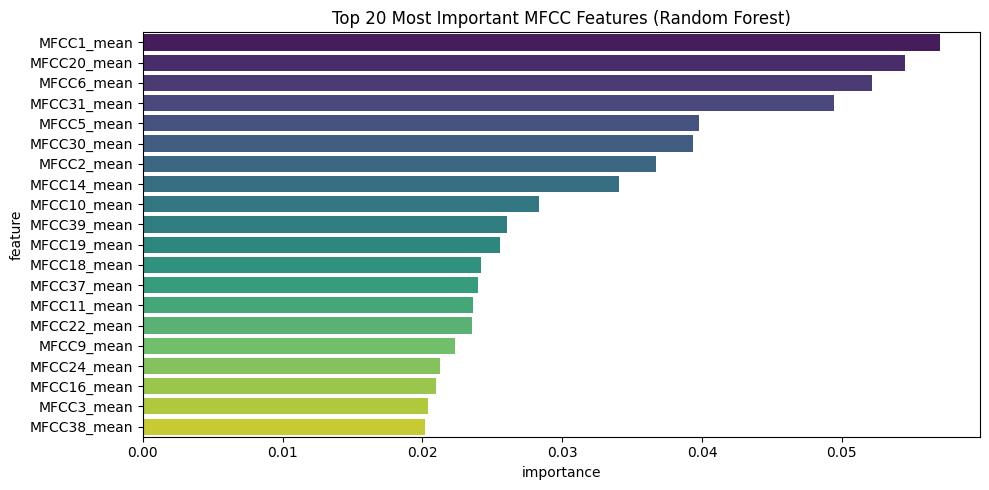

In [ ]:
importances = rf.feature_importances_
n = N_MFCC if "N_MFCC" in globals() else (len(importances) // 2)
labels = [f"MFCC{i+1}_mean" for i in range(n)] + [f"MFCC{i+1}_std" for i in range(n)]

feat_df = pd.DataFrame({"feature": labels, "importance": importances})
feat_df = feat_df.sort_values("importance", ascending=False).head(20)

plt.figure(figsize=(10, 5))
sns.barplot(data=feat_df, x="importance", y="feature", palette="viridis")
plt.title("Top 20 Most Important MFCC Features (Random Forest)")
plt.tight_layout()
plt.savefig("rf_feature_importance.png", dpi=150)
plt.show()

Wyliczamy lub wczytujemy z cache spektrogramy melowe dla CNN.

In [ ]:
MEL_CACHE = Path("mel_cache.npz")

if MEL_CACHE.exists():
    print("Loading cached Mel spectrograms...")
    mel_data = np.load(MEL_CACHE)
    X_mel = mel_data["X_mel"]
    y_mel = mel_data["y_mel"]
    print(f"Loaded. Shape: {X_mel.shape}")

else:
    df_fan = df_cache[df_cache["machine_type"] == "fan"].reset_index(drop=True)
    print(f"Extracting Mel spectrograms for {len(df_fan)} fan files...")

    X_mel, y_mel = [], []

    for _, row in tqdm(df_fan.iterrows(), total=len(df_fan)):
        try:
            wav = load_audio(row["path"])
            mel = librosa.feature.melspectrogram(y=wav, sr=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
            mel_db = librosa.power_to_db(mel, ref=np.max).astype(np.float32)
            X_mel.append(mel_db)
            y_mel.append(row["label"])
        except Exception as e:
            print(f"  Skipping {row['path']}: {e}")

    X_mel = np.array(X_mel, dtype=np.float32)   # (N, 128, time_frames)
    y_mel = np.array(y_mel, dtype=np.int64)

    np.savez(MEL_CACHE, X_mel=X_mel, y_mel=y_mel)
    print(f"Done. Shape: {X_mel.shape}")
    print(f"Saved to {MEL_CACHE}")

Loading cached Mel spectrograms...
Loaded. Shape: (5550, 128, 313)


Normalizujemy spektrogramy i tworzymy DataLoadery dla PyTorch.

In [8]:
# Ensure numpy arrays even if loaded from cache or built as lists
X_mel = np.asarray(X_mel, dtype=np.float32)
y_mel = np.asarray(y_mel, dtype=np.int64)

# Normalise each spectrogram to [0, 1]
X_mel_norm = (X_mel - X_mel.min()) / (X_mel.max() - X_mel.min() + 1e-8)

# Add channel dim → (N, 1, N_MELS, time_frames)
X_mel_norm = X_mel_norm[:, np.newaxis, :, :]

X_tr, X_te, y_tr, y_te = train_test_split(
    X_mel_norm, y_mel, test_size=0.2, random_state=42, stratify=y_mel
)

# Convert to tensors
X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr, dtype=torch.long)
X_te_t = torch.tensor(X_te, dtype=torch.float32)
y_te_t = torch.tensor(y_te, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_te_t, y_te_t), batch_size=32, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")
print(f"Input shape per sample: {X_tr_t.shape[1:]}")

Using device: cuda
Train batches: 139, Test batches: 35
Input shape per sample: torch.Size([1, 128, 313])


Definiujemy prosta siec CNN do klasyfikacji spektrogramow.

In [ ]:
class AudioCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # local time-frequency patterns
            nn.BatchNorm2d(32),                         # stabilize activations
            nn.ReLU(),                                  # non-linearity
            nn.MaxPool2d(2),                             # downsample

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # deeper feature maps
            nn.BatchNorm2d(64),                         # stabilize activations
            nn.ReLU(),                                  # non-linearity
            nn.MaxPool2d(2),                             # downsample

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),# higher-level features
            nn.BatchNorm2d(128),                        # stabilize activations
            nn.ReLU(),                                  # non-linearity
            nn.AdaptiveAvgPool2d((4, 4)),               # fixed-size output
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),                               # flatten feature maps
            nn.Linear(128 * 4 * 4, 256),                 # dense projection
            nn.ReLU(),                                  # non-linearity
            nn.Dropout(0.4),                             # regularization
            nn.Linear(256, 2),                           # 2 classes: normal / abnormal
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = AudioCNN().to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")

AudioCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(4, 4))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linea

Trenujemy CNN i zapisujemy metryki po kazdej epoce.

In [ ]:
EPOCHS    = 20
LR        = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):

    # --- Train ---
    model.train()
    train_loss, correct, total = 0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss  = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(yb)
        correct    += (preds.argmax(1) == yb).sum().item()
        total      += len(yb)

    # --- Validate ---
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds   = model(xb)
            loss    = criterion(preds, yb)
            val_loss    += loss.item() * len(yb)
            val_correct += (preds.argmax(1) == yb).sum().item()
            val_total   += len(yb)

    scheduler.step()

    t_loss = train_loss / total
    t_acc  = correct    / total
    v_loss = val_loss   / val_total
    v_acc  = val_correct / val_total

    history["train_loss"].append(t_loss)
    history["train_acc"].append(t_acc)
    history["val_loss"].append(v_loss)
    history["val_acc"].append(v_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train loss: {t_loss:.4f}  acc: {t_acc:.4f} | "
          f"Val loss: {v_loss:.4f}  acc: {v_acc:.4f}")

Epoch 01/20 | Train loss: 0.4848  acc: 0.7856 | Val loss: 1.9256  acc: 0.2667
Epoch 02/20 | Train loss: 0.1757  acc: 0.9365 | Val loss: 0.0747  acc: 0.9739
Epoch 03/20 | Train loss: 0.1058  acc: 0.9637 | Val loss: 1.6731  acc: 0.7721
Epoch 04/20 | Train loss: 0.0510  acc: 0.9831 | Val loss: 1.2198  acc: 0.7532
Epoch 05/20 | Train loss: 0.0493  acc: 0.9836 | Val loss: 0.3333  acc: 0.8784
Epoch 06/20 | Train loss: 0.0237  acc: 0.9935 | Val loss: 0.0197  acc: 0.9946
Epoch 07/20 | Train loss: 0.0286  acc: 0.9917 | Val loss: 0.0159  acc: 0.9964
Epoch 08/20 | Train loss: 0.0093  acc: 0.9973 | Val loss: 0.6033  acc: 0.7883
Epoch 09/20 | Train loss: 0.0072  acc: 0.9975 | Val loss: 0.0124  acc: 0.9964
Epoch 10/20 | Train loss: 0.0056  acc: 0.9984 | Val loss: 0.0145  acc: 0.9946
Epoch 11/20 | Train loss: 0.0099  acc: 0.9968 | Val loss: 0.1499  acc: 0.9568
Epoch 12/20 | Train loss: 0.0135  acc: 0.9946 | Val loss: 0.0086  acc: 0.9955
Epoch 13/20 | Train loss: 0.0032  acc: 0.9993 | Val loss: 0.0277

Rysujemy krzywe uczenia i porownujemy wyniki modeli.

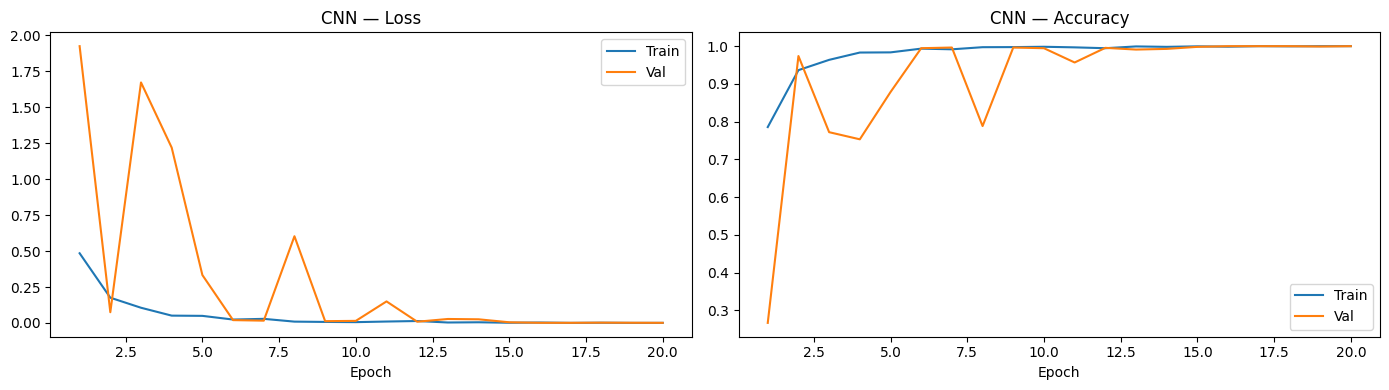

=== CNN ===
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00       815
    abnormal       1.00      1.00      1.00       295

    accuracy                           1.00      1110
   macro avg       1.00      1.00      1.00      1110
weighted avg       1.00      1.00      1.00      1110

ROC-AUC: 1.0000


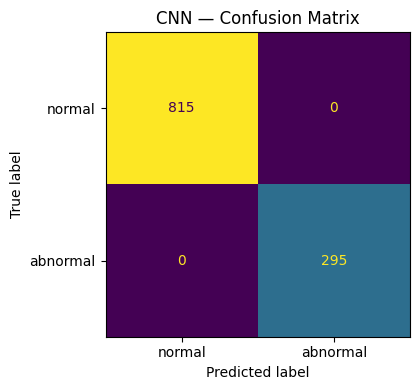


=== Model Comparison ===
        Model Accuracy ROC-AUC
Random Forest   1.0000  1.0000
          CNN   1.0000  1.0000


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, history["train_loss"], label="Train")
axes[0].plot(epochs_range, history["val_loss"],   label="Val")
axes[0].set_title("CNN — Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="Train")
axes[1].plot(epochs_range, history["val_acc"],   label="Val")
axes[1].set_title("CNN — Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig("cnn_training_curves.png", dpi=150)
plt.show()

# --- CNN confusion matrix ---
model.eval()
all_preds, all_proba = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        out = model(xb.to(device))
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_proba.extend(torch.softmax(out, dim=1)[:, 1].cpu().numpy())

print("=== CNN ===")
print(classification_report(y_te, all_preds, target_names=["normal", "abnormal"]))
print(f"ROC-AUC: {roc_auc_score(y_te, all_proba):.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_te, all_preds),
                       display_labels=["normal", "abnormal"]).plot(ax=ax, colorbar=False)
ax.set_title("CNN — Confusion Matrix")
plt.tight_layout()
plt.savefig("cnn_confusion_matrix.png", dpi=150)
plt.show()

# --- Side-by-side summary ---
rf_acc  = (y_pred_rf == y_test).mean()
cnn_acc = (np.array(all_preds) == y_te).mean()
rf_auc  = roc_auc_score(y_test, y_proba_rf)
cnn_auc = roc_auc_score(y_te, all_proba)

summary = pd.DataFrame({
    "Model":    ["Random Forest", "CNN"],
    "Accuracy": [f"{rf_acc:.4f}", f"{cnn_acc:.4f}"],
    "ROC-AUC":  [f"{rf_auc:.4f}", f"{cnn_auc:.4f}"],
})
print("\n=== Model Comparison ===")
print(summary.to_string(index=False))